## AutoEncoders
Instead of labels, we will use training images as both network input and output. The main idea of **autoencoder** is that we will have an encoder network that *converts input image into some latent space* (normally it is just a vector of some smaller size), then the decoder network, whose goal would be to reconstruct the original image.

In [24]:
import os
os.environ["HTTP_PROXY"] = "http://127.0.0.1:3128"
os.environ["HTTPS_PROXY"] = "http://127.0.0.1:3128"

import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms
from torch import nn, optim
from tqdm import tqdm
import numpy as np
import torch.nn.functional as F
torch.manual_seed(42)
np.random.seed(42)

In [25]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

train_size = 0.9
lr = 1e-3
eps = 1e-8
batch_size = 256
epochs = 30

In [26]:
def mnist(train_part, transform = None):
    dataset = torchvision.datasets.MNIST('../../data', download = True, transform = transform)
    train_part = int(train_part * len(dataset))
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_part, len(dataset) - train_part])

    return train_dataset, test_dataset

In [27]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

train_dataset, test_dataset = mnist(train_size, transform)

train_loader = torch.utils.data.DataLoader(train_dataset, drop_last = True, batch_size = batch_size, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 1, shuffle = False)
dataloaders = (train_loader, test_loader)

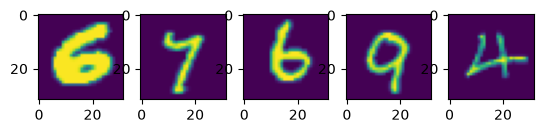

In [28]:
def plotn(n, data, noisy=False, super_res=None):
    fig, ax = plt.subplots(1, n)
    for i, z in enumerate(data):
        if i == n:
            break
        preprocess = z[0].reshape(1, 28, 28) if z[0].shape[1] == 28 else z[0].reshape(1, 14, 14) if z[0].shape[1] == 14 else z[0]
        if super_res is not None:
            _transform = transforms.Resize((int(preprocess.shape[1] / super_res), int(preprocess.shape[2] / super_res)))
            preprocess = _transform(preprocess)

        if noisy:
            shapes = list(preprocess.shape)
            preprocess += noisify(shapes)

        ax[i].imshow(preprocess[0])
    plt.show()

def noisify(shapes):
    return np.random.normal(loc=0.5, scale=0.3, size=shapes)

plotn(5, train_dataset)

In [49]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, 3, padding='same')
        self.maxpool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 8, 3, padding='same')
        self.maxpool2 = nn.MaxPool2d(2)

        self.relu = nn.ReLU()

    def forward(self, input):
        hidden1 = self.maxpool1(self.relu(self.conv1(input)))
        encoded = self.maxpool2(self.relu(self.conv2(hidden1)))

        return encoded

In [50]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(8, 8, 3, padding='same')
        self.upsample1 = nn.Upsample(scale_factor=(2, 2))
        
        self.conv2 = nn.Conv2d(8, 16, 3, padding='same')
        self.upsample2 = nn.Upsample(scale_factor=(2, 2))
        
        self.conv3 = nn.Conv2d(16, 1, 3, padding='same')
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, input):
        hidden1 = self.upsample1(self.relu(self.conv1(input)))
        hidden2 = self.upsample2(self.relu(self.conv2(hidden1)))
        decoded = self.sigmoid(self.conv3(hidden2))

        return decoded

In [59]:
class AutoEncoder(nn.Module):
    def __init__(self, super_resolution = False):
        super().__init__()
        if not super_resolution:
            self.encoder = Encoder()
        else:
            self.encoder = SuperResolutionEncoder()

        self.decoder = Decoder()

    def forward(self, input):
        encoded = self.encoder(input)
        decoded = self.decoder(encoded)

        return decoded

In [52]:
model = AutoEncoder().to(device)
optimizer = optim.Adam(model.parameters(), lr = lr, eps = eps)
loss_fn = nn.BCELoss()

In [33]:
def train(dataloaders, model, loss_fn, optimizer, epochs, device, noisy=None, super_res=None):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader, test_dataloader = dataloaders[0], dataloaders[1]

    for epoch in tqdm_iter:
        model.train()
        train_loss = 0.0
        test_loss = 0.0

        for batch in train_dataloader:
            imgs, labels = batch
            shapes = list(imgs.shape)

            if super_res is not None:
                shapes[2], shapes[3] = int(shapes[2] / super_res), int(shapes[3] / super_res)
                _transform = transforms.Resize((shapes[2], shapes[3]))
                imgs_transformed = _transform(imgs)
                imgs_transformed = imgs_transformed.to(device)

            imgs = imgs.to(device)
            labels = labels.to(device)

            if noisy is not None:
                noisy_tensor = noisy[0]
            else:
                noisy_tensor = torch.zeros(tuple(shapes)).to(device)

            if super_res is None:
                imgs_noisy = imgs + noisy_tensor
            else:
                imgs_noisy = imgs_transformed + noisy_tensor

            imgs_noisy = torch.clamp(imgs_noisy, 0., 1.)

            preds = model(imgs_noisy)
            loss = loss_fn(preds, imgs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            for batch in test_dataloader:
                imgs, labels = batch
                shapes = list(imgs.shape)

                if super_res is not None:
                    shapes[2], shapes[3] = int(shapes[2] / super_res), int(shapes[3] / super_res)
                    _transform = transforms.Resize((shapes[2], shapes[3]))
                    imgs_transformed = _transform(imgs)
                    imgs_transformed = imgs_transformed.to(device)


                imgs = imgs.to(device)
                labels = labels.to(device)

                if noisy is not None:
                    test_noisy_tensor = noisy[1]
                else:
                    test_noisy_tensor = torch.zeros(tuple(shapes)).to(device)

                if super_res is None:
                    imgs_noisy = imgs + test_noisy_tensor
                else:
                    imgs_noisy = imgs_transformed + test_noisy_tensor

                imgs_noisy = torch.clamp(imgs_noisy, 0., 1.)

                preds = model(imgs_noisy)
                loss = loss_fn(preds, imgs)

                test_loss += loss.item()

        train_loss /= len(train_dataloader)
        test_loss /= len(test_dataloader)

        tqdm_dct = {'train loss:': train_loss, 'test loss:': test_loss}
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()

In [34]:
# train(dataloaders, model, loss_fn, optimizer, epochs, device)

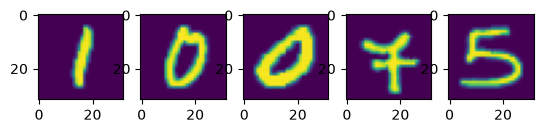

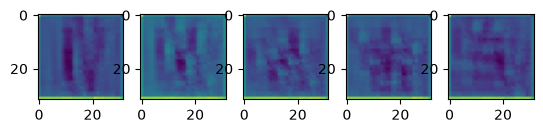

In [35]:
model.eval()
predictions = []
plots = 5

for i, data in enumerate(test_dataset):
    if i == plots:
        break

    predictions.append(model(data[0].to(device).unsqueeze(0)).detach().cpu())

plotn(plots, test_dataset)
plotn(plots, predictions)

### Task 1:
Try to train autoencoder with very small latent vector size, eg. 2, and plot the dots corresponding to different digits. Hint: Use fully-connected dense layer after the convoluitonal part to reduce the vector size to the required value.

In [36]:
# Adjusting Encoder and Decoder
class Encoder2D(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, 3, padding = 'same')
        self.maxpool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 8, 3, padding = 'same')
        self.maxpool2 = nn.MaxPool2d(2)

        self.relu = nn.ReLU()

        #Dense layer to reduce vector size to 2
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(8 * 8 * 8, 2)

    def forward(self, input):
        hidden1 = self.maxpool1(self.relu(self.conv1(input)))
        hidden2 = self.maxpool2(self.relu(self.conv2(hidden1)))
        encoded = self.fc(self.flatten(hidden2))

        return encoded

class Decoder2D(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(2, 8 * 8 * 8)
        self.conv1 = nn.Conv2d(8, 8, 3, padding='same')
        self.upsample1 = nn.Upsample(scale_factor = (2, 2))

        self.conv2 = nn.Conv2d(8, 16, 3, padding='same')
        self.upsample2 = nn.Upsample(scale_factor = (2, 2))

        self.conv3 = nn.Conv2d(16, 1, 3, padding = 'same')

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, input):
        input = self.fc(input)
        input = input.view(-1, 8, 8, 8) #Reshape back to 3D tensor

        hidden1 = self.upsample1(self.relu(self.conv1(input)))
        hidden2 = self.upsample2(self.relu(self.conv2(hidden1)))
        decoded = self.sigmoid(self.conv3(hidden2))

        return decoded

class AutoEncoder2D(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = Encoder2D()
        self.decoder = Decoder2D()

    def forward(self, input):
        encoded = self.encoder(input)
        decoded = self.decoder(encoded)

        return decoded, encoded  # Return both decoded and encoded latent vector for visualization


model = AutoEncoder2D().to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-3, eps = 1e-8)
loss_fn = nn.BCELoss()


In [37]:
epochs = 15
for epoch in range(epochs):
    model.train()

    for imgs, _ in tqdm(train_loader, desc = f"Epoch {epoch + 1}"):
        imgs = imgs.to(device)
        preds, _ = model(imgs)

        loss = loss_fn(preds, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

model.eval()
latent_vectors = []
labels_list = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        _, latent = model(imgs)

        latent_vectors.append(latent.cpu().numpy())
        labels_list.append(labels.numpy())

latent_vectors = np.concatenate(latent_vectors, axis=0)
labels_list = np.concatenate(labels_list, axis=0)

# Plotting the latent space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], c=labels_list, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(10))
plt.title("2D Latent Space Representation of MNIST Digits")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True)
plt.show()


Epoch 1:  84%|████████▍ | 176/210 [00:06<00:01, 25.78it/s]


KeyboardInterrupt: 

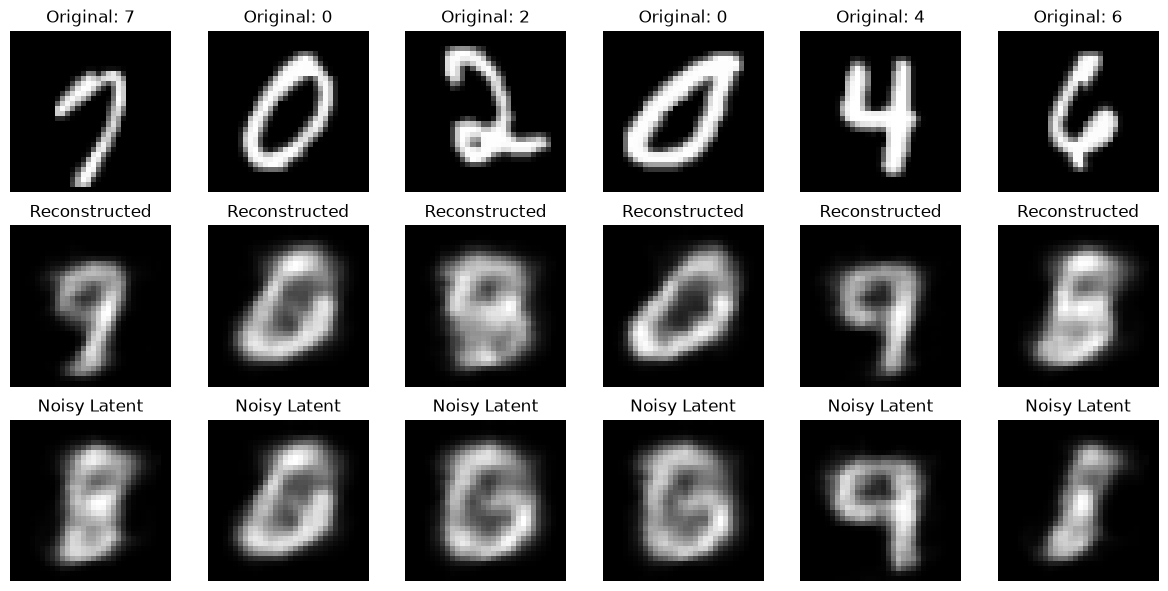

In [ ]:
def visualize_noise_effect(model, dataset, num_samples=5, noise_scale=1.5):
    model.eval()
    fig, axes = plt.subplots(3, num_samples, figsize=(num_samples * 2, 6))
    
    with torch.no_grad():
        for i in range(num_samples):
            # Get original image
            img, label = dataset[i]
            img_input = img.unsqueeze(0).to(device)
            
            # Encode and decode original
            reconstructed, latent = model(img_input)
            
            # Add noise to latent space and decode
            noise = torch.randn_like(latent) * noise_scale
            noisy_latent = latent + noise
            noisy_reconstructed = model.decoder(noisy_latent)
            
            # Plot Original
            axes[0, i].imshow(img.squeeze(), cmap='gray')
            axes[0, i].set_title(f"Original: {label}")
            axes[0, i].axis('off')
            
            # Plot Reconstructed
            axes[1, i].imshow(reconstructed.cpu().squeeze(), cmap='gray')
            axes[1, i].set_title("Reconstructed")
            axes[1, i].axis('off')
            
            # Plot Noisy Reconstruction
            axes[2, i].imshow(noisy_reconstructed.cpu().squeeze(), cmap='gray')
            axes[2, i].set_title(f"Noisy Latent")
            axes[2, i].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_noise_effect(model, test_dataset, num_samples=6, noise_scale=0.5)

### Denoising
Autoencoders can be effectively used to remove noise from images. In order to train denoiser, we will start with noise-free images, and add artificial noise to them. Then, we will feed autoencoder with noisy images as input, and noise-free images as output.

C:\Users\DLA7HC\AppData\Local\Temp\ipykernel_14700\2480129209.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  preprocess += noisify(shapes)


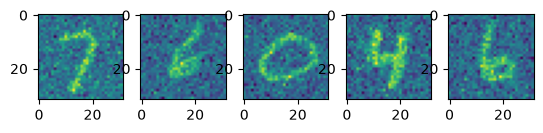

In [ ]:
plotn(5, train_dataset, noisy = True)

In [38]:
model = AutoEncoder().to(device)
optimizer = optim.Adam(model.parameters(), lr = lr, eps = eps)
loss_fn = nn.BCELoss()

In [41]:
noisy_tensor = torch.FloatTensor(noisify([256, 1, 32, 32])).to(device)
test_noisy_tensor = torch.FloatTensor(noisify([1, 1, 32, 32])).to(device)

noisy_tensors = (noisy_tensor, test_noisy_tensor)

In [42]:
train(dataloaders, model, loss_fn, optimizer, 100, device, noisy = noisy_tensors)

100%|██████████| 100/100 [31:57<00:00, 19.17s/it, train loss:=0.113, test loss:=0.112]


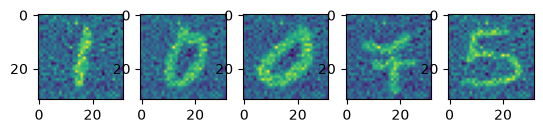

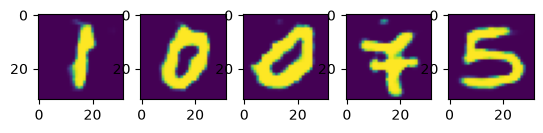

In [44]:
model.eval()
predictions = []
noise = []
plots = 5

for i, data in enumerate(test_dataset):
    if i == plots:
        break

    noisy_data = data[0] + test_noisy_tensor[0].detach().cpu()
    noise.append([noisy_data])

    predictions.append(model(noisy_data.to(device).unsqueeze(0)).detach().cpu())

plotn(plots, noise)
plotn(plots, predictions)

### Super-resolution
Similarly to denoiser, we can train autoencoders to increase the resolution of the image. To train super-resolution network, we will start with high-resolution images, and automatically downscale them to produce network inputs. We will then feed autoencoder with small images as inputs and high-resolution images as outputs.

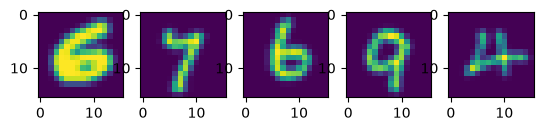

In [45]:
# Downscale image to 14x14 at train.
super_res_koeff = 2.0
plotn(5, train_dataset, super_res = super_res_koeff)

In [70]:
class SuperResolutionEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, 3, padding='same')
        self.maxpool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 8, 3, padding='same')
        # self.maxpool2 = nn.MaxPool2d(2, padding = (1, 1)) 

        self.relu = nn.ReLU()

    def forward(self, input):
        hidden1 = self.maxpool1(self.relu(self.conv1(input)))
        # encoded = self.maxpool2(self.relu(self.conv2(hidden1)))
        encoded = self.relu(self.conv2(hidden1))

        return encoded

In [71]:
model = AutoEncoder(super_resolution = True).to(device)
optimizer = optim.Adam(model.parameters(), lr = lr, eps = eps)
loss_fn = nn.BCELoss()

In [72]:
train(dataloaders, model, loss_fn, optimizer, 30, device, super_res = 2.0)

100%|██████████| 30/30 [11:52<00:00, 23.75s/it, train loss:=0.101, test loss:=0.101]


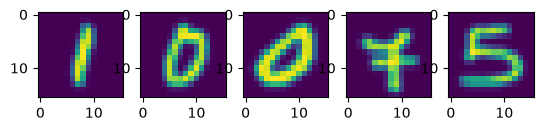

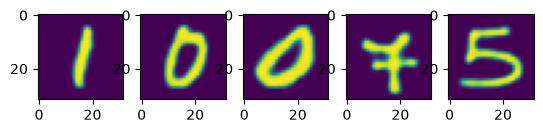

In [76]:
model.eval()
predictions = []
plots = 5
shapes = test_dataset[0][0].shape

for i, data in enumerate(test_dataset):
    if i == plots:
        break

    _transform = transforms.Resize((int(shapes[1] / super_res_koeff), int(shapes[2] / super_res_koeff)))
    predictions.append(model(_transform(data[0]).to(device).unsqueeze(0)).detach().cpu())

plotn(plots, test_dataset, super_res = super_res_koeff)
plotn(plots, predictions)

## Variational Auto-Encoders (VAE)
Traditional autoencoders reduce the dimension of the input data somehow, figuring out the important features of input images. However, latent vectors often do not make much sense. In other words, taking MNIST dataset as an example, figuring out which digits correspond to different latent vectors is not an easy task, because close latent vectors would not necessarily correspond to the same digits.

On the other hand, to train generative models it is better to have some understanding of the **latent space**. This idea leads us to **variational auto-encoder** (VAE).

VAE is the autoencoder that learns to predict **statistical distribution** of the latent parameters, so-called **latent distribution**. 

In [ ]:
class VAEEncoders(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.intermediate = 512
        self.latent_dim = 2
        
        self.linear = nn.Linear(784, self.intermediate)
        self.z_mean = nn.Linear(self.intermediate, self.latent_dim)
        self.z_log = nn.Linear(self.intermediate, self.latent_dim)
        self.relu = nn.ReLU()
        self.device = device
        
    def forward(self, input):
        bs = input.shape[0]
        
        hidden = self.relu(self.linear(input))
        z_mean = self.z_mean(hidden)
        z_log = self.z_log(hidden)
        
        eps = torch.FloatTensor(np.random.normal(size = (bs, self.latent_dim))).to(self.device)
        z_val = z_mean + torch.exp(z_log / 2) * eps
        
        return z_mean, z_log, z_val

In [ ]:
class VAEDecoders(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.intermediate = 512
        self.latent_dim = 2
        
        self.linear = nn.Linear(self.latent_dim, self.intermediate)
        self.output = nn.Linear(self.intermediate, 784)     # 28x28 images
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, input):
        hidden = self.relu(self.linear(input))
        output = self.sigmoid(self.output(hidden))
        
        return output

In [ ]:
class VAEAutoEncoder(nn.Moduel):
    def __init__(self):
        super().__init__()
        
        self.encoder = VAEEncoders()
        self.decoder = VAEDecoders()
        self.z_val = None
        
    def forward(self, input):
        bs, c, h, w = input.shape[0], input.shape[1], input.shape[2], input.shape[3]
        input = input.view(bs, -1) # Takes a 2D image batch (batch size, channels, height, width) and squashes it into a flat, 1D vector for each image.
        
        encoded = self.encoder(input)
        self.z_val = encoded
        decoded = self.decoder(encoded[2])
        
        return decoded
    
    def get_z_vals(self):
        return self.z_vals

### Loss Function
- **Reconstruction loss**: This is measured how close the reconstructed images is to the target
- **KL Loss**: This ensures the latent variable distributions remain close to a normal distribution.

In [ ]:
def vae_loss(preds, targets, z_vals):
    mse = nn.MSELoss()
    reconstruction_loss = mse(preds, targets.view(targets.shape[0], -1)) * 784  # Scale the reconstruction loss by the number of pixels
    temp = 1.0 + z_vals[1] - torch.square(z_vals[0]) - torch.exp(z_vals[1])
    kl_loss = -0.5 * torch.sum(temp, axis=-1)
    
    return torch.mean(reconstruction_loss + kl_loss)

In [ ]:
model = VAEAutoEncoder().to(device)
optimizer = optim.Adam(model.parameters(), lr = lr, eps = eps)

In [ ]:
def vae_train(dataloader, model, optimizer, epochs, device):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader, test_dataloader = dataloader[0], dataloader[1]
    
    for epoch in tqdm_iter:
        model.train()
        train_loss = 0.0
        
        for batch in train_dataloader:
            imgs, labels = batch
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            preds = model(imgs)
            z_vals = model.get_z_vals()
            loss = vae_loss(preds, imgs, z_vals)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        model.eval()
        with torch.no_grad():
            for batch in test_dataloader:
                imgs, labels = batch
                imgs = imgs.to(device)
                labels = labels.to(device)
                
                preds = model(imgs)
                z_vals = model.get_z_vals()
                loss = vae_loss(preds, imgs, z_vals)
                test_loss += loss.item()
        
        train_loss /= len(train_dataloader)
        test_loss /= len(test_dataloader)
        
        tqdm_dct = {'train loss:': train_loss, 'test loss:': test_loss}
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()

In [ ]:
vae_train(dataloaders, model, optimizer, 30, device)

In [ ]:
model.eval()
predictions = []
plots = 5
for i, data in enumerate(test_dataset):
    if i == plots:
        break

    predictions.append(model(data[0].to(device).unsqueeze(0)).detach().cpu())

plotn(plots, test_dataset)
plotn(plots, predictions)

## Adversarial Auto-Encoders (AAE)
AAE is a **combination** of **GANs** and **VAE**
- The encoder acts as a generator, while the discriminator learns to differentiate between real images and the encoder's output. 
- The encoder's output is a distribution, and the decoder attempts to reconstruct the image from this output.

In [ ]:
class AAEEncoders(nn.Module):
    def __init__(self, input_dim, intermediate_dim, latent_dim):
        super().__init__()
        
        self.linear1 = nn.Linear(input_dim, intermediate_dim)
        self.linear2 = nn.Linear(intermediate_dim, intermediate_dim)
        self.linear3 = nn.Linear(intermediate_dim, intermediate_dim)
        self.linear4 = nn.Linear(intermediate_dim, latent_dim)
        self.relu = nn.ReLU()
        
    def forward(self, input):
        hidden1 = self.relu(self.linear1(input))
        hidden2 = self.relu(self.linear2(hidden1))
        hidden3 = self.relu(self.linear3(hidden2))
        encoded = self.linear4(hidden3)
        
        return encoded
    
class AAEDecoders(nn.Module):
    def __init__(self, latent_dim, intermediate_dim, output_dim):
        super().__init__()
        
        self.linear1 = nn.Linear(latent_dim, intermediate_dim)
        self.linear2 = nn.Linear(intermediate_dim, intermediate_dim)
        self.linear3 = nn.Linear(intermediate_dim, intermediate_dim)
        self.linear4 = nn.Linear(intermediate_dim, output_dim)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, input):
        hidden1 = self.relu(self.linear1(input))
        hidden2 = self.relu(self.linear2(hidden1))
        hidden3 = self.relu(self.linear3(hidden2))
        decoded = self.sigmoid(self.linear4(hidden3))
        
        return decoded
    
class AAEDiscriminator(nn.Module):
    def __init__(self, latent_dim, intermediate_dim):
        super().__init__()
        
        self.latent_dim = latent_dim
        self.intermediate_dim = intermediate_dim
        
        self.linear1 = nn.Linear(latent_dim, intermediate_dim)
        self.linear2 = nn.Linear(intermediate_dim, intermediate_dim)
        self.linear3 = nn.Linear(intermediate_dim, intermediate_dim)
        self.linear4 = nn.Linear(intermediate_dim, intermediate_dim)
        self.linear5 = nn.Linear(intermediate_dim, 1)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, input):
        hidden1 = self.relu(self.linear1(input))
        hidden2 = self.relu(self.linear2(hidden1))
        hidden3 = self.relu(self.linear3(hidden2))
        hidden4 = self.relu(self.linear4(hidden3))
        output = self.sigmoid(self.linear5(hidden4))
        
        return output
    
    def get_dims(self):
        return self.latent_dim, self.intermediate_dim

In [ ]:
inputs_dim = 784
intermediate_dim = 1000
latent_dim = 150

lr = 1e-4
regularization_lr = 5e-5

In [ ]:
aae_encoder = AAEEncoders(inputs_dim, intermediate_dim, latent_dim).to(device)
aae_decoder = AAEDecoders(latent_dim, intermediate_dim, inputs_dim).to(device)
aae_discriminator = AAEDiscriminator(latent_dim, intermediate_dim).to(device)

optim_encoder = optim.Adam(aae_encoder.parameters(), lr = lr)
optim_encoder_regularization = optim.Adam(aae_decoder.parameters(), lr = regularization_lr)
optim_decoder = optim.Adam(aae_decoder.parameters(), lr = lr)
optim_discriminator = optim.Adam(aae_discriminator.parameters(), lr = regularization_lr)

In [ ]:
def train_aae(dataloaders, models, optimizers, epochs, device):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader, test_dataloader = dataloaders[0], dataloaders[1]
    
    encoder, decoder, discriminator = models
    optim_encoder, optim_encoder_regularization, optim_decoder, optim_discriminator = optimizers
    
    eps = 1e-9
    
    for epoch in range(epochs):
        encoder.train()
        decoder.train()
        discriminator.train()
        
        train_recontruction_loss = 0.0
        train_discriminator_loss = 0.0
        train_encoder_loss = 0.0
        
        test_reconstruction_loss = 0.0
        test_discriminator_loss = 0.0
        test_encoder_loss = 0.0
        
        for batch in train_dataloader:
            imgs, labels = batch
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            encoder.zero_grad()
            decoder.zero_grad()
            discriminator.zero_grad()
            
            # Flatten the images for the encoder and decoder
            imgs_flattened = imgs.view(imgs.size(0), -1)
            
            # Forward pass through the encoder and decoder
            encoded = encoder(imgs_flattened)
            decoded = decoder(encoded)
            
            # Compute reconstruction loss
            reconstruction_loss = F.binary_cross_entropy(decoded, imgs_flattened)
            reconstruction_loss.backward()
            
            optim_encoder.step()
            optim_decoder.step()
            encoder.eval()
            
            latent_dim, intermediate_dim = discriminator.get_dims()
            real = torch.randn(imgs.size(0), latent_dim).to(device)
            
            discriminator_real = discriminator(real)
            discriminator_fake = discriminator(encoded(imgs_flattened))
            
            discriminator_loss = -torch.mean(torch.log(discriminator_real + eps) + torch.log(1 - discriminator_fake + eps))
            discriminator_loss.backward()
            
            optim_decoder.step()
            encoder.train()
            
            discriminator_fake = discriminator(encoded(imgs_flattened))
            encoder_loss = -torch.mean(torch.log(discriminator_fake + eps))
            encoder_loss.backward()
            
            optim_encoder_regularization.step()
            
            train_recontruction_loss += reconstruction_loss.item()
            train_discriminator_loss += discriminator_loss.item()
            train_encoder_loss += encoder_loss.item()
            
        encoder.eval()
        decoder.eval()
        discriminator.eval()
            
        with torch.no_grad():
            for batch in test_dataloader:
                imgs, labels = batch
                imgs = imgs.to(device)
                labels = labels.to(device)
                
                # Flatten the images for the encoder and decoder
                imgs_flattened = imgs.view(imgs.size(0), -1)
                
                # Forward pass through the encoder and decoder
                encoded = encoder(imgs_flattened)
                decoded = decoder(encoded)
                
                # Compute reconstruction loss
                reconstruction_loss = F.binary_cross_entropy(decoded, imgs_flattened)
                
                latent_dim, intermediate_dim = discriminator.get_dims()
                real = torch.randn(imgs.size(0), latent_dim).to(device)
                
                discriminator_real = discriminator(real)
                discriminator_fake = discriminator(encoded(imgs_flattened))
                
                discriminator_loss = -torch.mean(torch.log(discriminator_real + eps) + torch.log(1 - discriminator_fake + eps))
                
                discriminator_fake = discriminator(encoded(imgs_flattened))
                encoder_loss = -torch.mean(torch.log(discriminator_fake + eps))
                
                test_reconstruction_loss += reconstruction_loss.item()
                test_discriminator_loss += discriminator_loss.item()
                test_encoder_loss += encoder_loss.item()
                
        train_recontruction_loss /= len(train_dataloader)
        train_discriminator_loss /= len(train_dataloader)
        train_encoder_loss /= len(train_dataloader)
        
        test_reconstruction_loss /= len(test_dataloader)
        test_discriminator_loss /= len(test_dataloader)
        test_encoder_loss /= len(test_dataloader)
        
        tqdm_dct = {
            'train reconstruction loss:': train_recontruction_loss,
            'train discriminator loss:': train_discriminator_loss,
            'train encoder loss:': train_encoder_loss,
            'test reconstruction loss:': test_reconstruction_loss,
            'test discriminator loss:': test_discriminator_loss,
            'test encoder loss:': test_encoder_loss
        }
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()

In [ ]:
models = (aae_encoder, aae_decoder, aae_discriminator)
optimizers = (optim_encoder, optim_encoder_regularization, optim_decoder, optim_discriminator)

train_aae(dataloaders, models, optimizers, 30, device)

In [ ]:
aae_encoder.eval()
aae_decoder.eval()
predictions = []
plots = 10

for i, data in enumerate(test_dataset):
    if i == plots:
        break

    img = data[0].to(device).unsqueeze(0)
    img_flattened = img.view(img.size(0), -1)
    encoded = aae_encoder(img_flattened)
    decoded = aae_decoder(encoded)

    predictions.append(decoded.detach().cpu().view(1, 28, 28))
    
plotn(plots, test_dataset)
plotn(plots, predictions)